# 01 — Building Euclidean Tilings

Eucare can build tilings from by growing rings of *prototiles* outward from a seed face. These are defined by sets of *prototiles* which have information on their edges on which tiles to attach (which will again have this information, allowing for iterative growth of the tiling). 

This notebook covers:

- the three regular Platonic tilings,
- some Archimedean tilings via convenient factories.

In [1]:
import os
os.environ.setdefault('TQDM_DISABLE', '1')

import matplotlib
matplotlib.rcParams['figure.figsize'] = (5, 5)
import matplotlib.pyplot as plt
import numpy as np

import eucare as ec
from eucare import (
    example_graphs,
    example_tilesets,
)
from eucare.rendering import multi_show


## The three regular tilings

`platonic(n)` returns a list of prototiles that tile the plane regularly for `n ∈ {3, 4, 6}` (triangles, squares, hexagons).

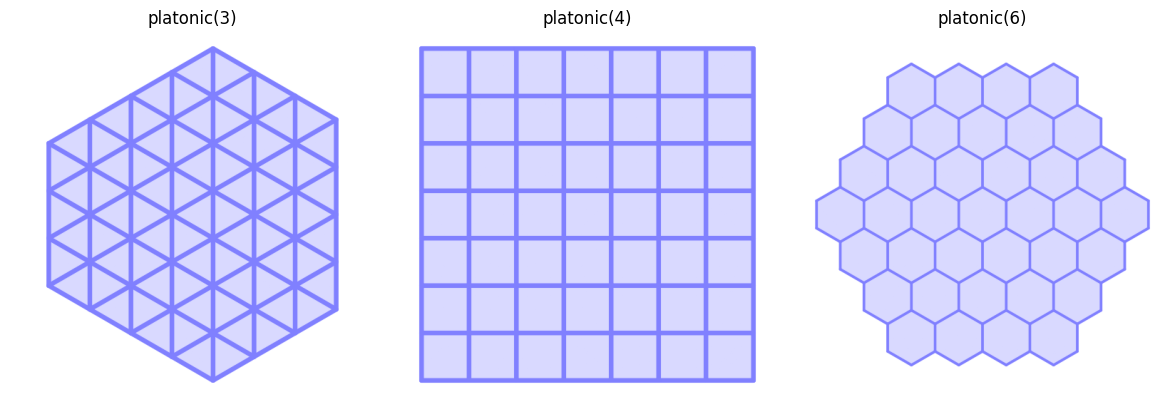

In [3]:
Gs, names = [], []
for n in [3, 4, 6]:
    G = example_graphs.from_tiles(example_tilesets.platonic(n), rings=3)
    G.recompute_lengths_and_angles()
    Gs.append(G); names.append(f'platonic({n})')
multi_show(Gs, titles=names, face_inset=0.05, render_vertices=False)


## Archimedean tilings

`example_tilesets` provides several Archimedean tilings as named factories. Each returns a list of prototiles you pass to `from_tiles`.

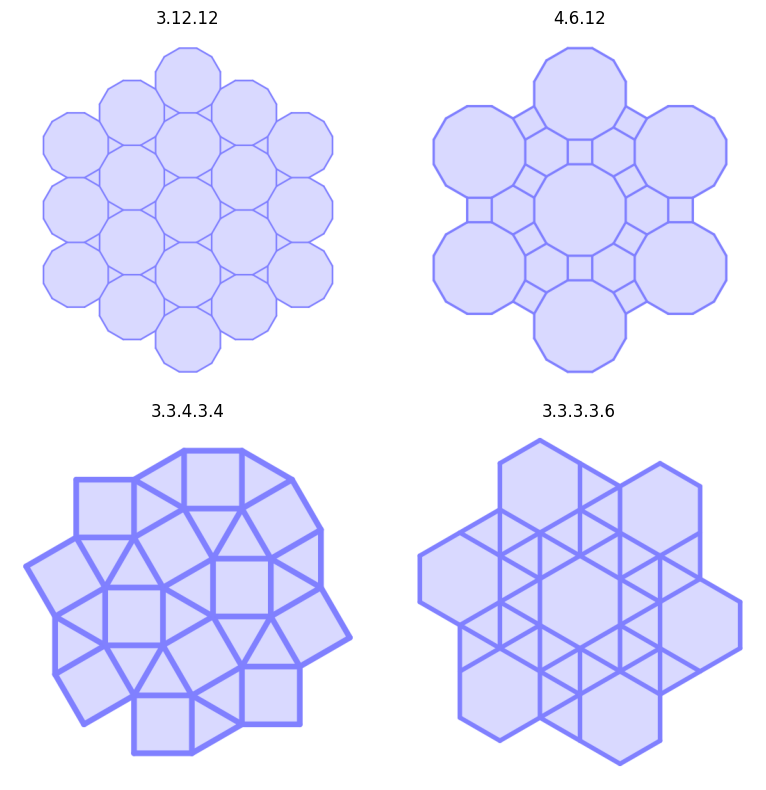

In [5]:
factories = [
    ('3.12.12',     example_tilesets.t_3_12_12),
    ('4.6.12',      example_tilesets.t_4_6_12),
    ('3.3.4.3.4',   example_tilesets.t_3_3_4_3_4),
    ('3.3.3.3.6',   example_tilesets.t_3_3_3_3_6),
]
Gs = []
for _, factory in factories:
    G = example_graphs.from_tiles(factory(), rings=2)
    G.recompute_lengths_and_angles()
    Gs.append(G)
multi_show(Gs, titles=[name for name, _ in factories],
           face_inset=0.05, render_vertices=False, ncols=2)
